In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.inversion.time_lapse import TimeLapseERTInversion
from PyHydroGeophysX.inversion.windowed import WindowedTimeLapseERTInversion

In [2]:



data_dir = "results/TL_measurements/appres"

# List of ERT data files testing monthly time-lapse inversion
ert_files = [
    "synthetic_data30.dat",
    "synthetic_data60.dat",
    "synthetic_data90.dat",
    "synthetic_data120.dat",
    "synthetic_data150.dat",
    "synthetic_data180.dat",
    "synthetic_data210.dat",
    "synthetic_data240.dat",
    "synthetic_data270.dat",
    "synthetic_data300.dat",
    "synthetic_data330.dat",
    "synthetic_data360.dat",
]


# Full paths to data files
data_files = [os.path.join(data_dir, f) for f in ert_files]

# Measurement times (can be timestamps or any sequential numbers representing time)
# Measurement times (can be timestamps or any sequential numbers representing time)
measurement_times = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # Adjust based on your actual acquisition times

# Create a mesh for the inversion (or load an existing one)
data = ert.load(os.path.join(data_dir, ert_files[0]))
ert_manager = ert.ERTManager(data)
mesh_with_interface = pg.load("results/Structure_WC/mesh_with_interface.bms")


In [43]:

# Set up inversion parameters
inversion_params = {
    "lambda_val": 5.0,              # Regularization parameter
    "alpha": 5.0,                   # Temporal regularization parameter
    "decay_rate": 0.0,               # Temporal decay rate
    "method": "cgls",                # Solver method ('cgls', 'lsqr', etc.)
    "model_constraints": (0.001, 1e4), # Min/max resistivity values (ohm-m)
    "max_iterations": 15,            # Maximum iterations
    "absoluteUError": 0.0,           # Absolute data error (V)
    "relativeError": 0.05,           # Relative data error (5%)
    "lambda_rate": 1.0,              # Lambda reduction rate
    "lambda_min": 1.0,               # Minimum lambda value
    "inversion_type": "L2"           # 'L1', 'L2', or 'L1L2'
}

# Define the window size (number of timesteps to process together)
window_size = 3  # A window size of 3 means each window includes 3 consecutive measurements

# Create the windowed time-lapse inversion object
inversion = WindowedTimeLapseERTInversion(
    data_dir=data_dir,               # Directory containing ERT data files
    ert_files=ert_files,             # List of ERT data filenames
    measurement_times=measurement_times,  # List of measurement times
    window_size=window_size,         # Size of sliding window
    mesh=mesh_with_interface,                       # Mesh for inversion
    **inversion_params               # Pass the same inversion parameters
)

# Run the inversion, optionally in parallel
print("Starting windowed time-lapse inversion...")
result = inversion.run()
print("Inversion complete!")


Starting windowed time-lapse inversion...

Processing 10 windows sequentially...
Using L2 inversion

Starting L2 inversion for window 0


23/06/25 - 16:02:09 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 16:02:09 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 16:02:09 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 16:02:09 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 16:02:09 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 16:02:09 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 16:02:10 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 16:02:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 16:02:10 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390


-6.907755278982137 9.210340371976184
-------------------ERT Iteration: 0 ---------------------------


23/06/25 - 16:02:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 16:02:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 16:02:42 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390
23/06/25 - 16:03:10 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 16:03:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 16:03:11 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390


ERT chi2: 1235.9014104071352
dPhi: 1.0
ERTphi_d: 3069979.1034513237, ERTphi_m: 0.0, ERTphi_t: 0.0
-------------------ERT Iteration: 1 ---------------------------
ERT chi2: 34.975933297076985
dPhi: 0.9717000619931689
ERTphi_d: 86880.21830993923, ERTphi_m: 2193.882081771602, ERTphi_t: 1039.3324207331225
-------------------ERT Iteration: 2 ---------------------------
ERT chi2: 22.50283346128475
dPhi: 0.35661949975283824
ERTphi_d: 55897.03831783132, ERTphi_m: 955.939162403387, ERTphi_t: 934.3853672101875
-------------------ERT Iteration: 3 ---------------------------
ERT chi2: 14.471537622443268
dPhi: 0.3569015365402324
ERTphi_d: 35947.29945414908, ERTphi_m: 589.6174407706301, ERTphi_t: 932.0816902379795
-------------------ERT Iteration: 4 ---------------------------
ERT chi2: 2.9447886859113406
dPhi: 0.7965116933155466
ERTphi_d: 7314.8550958037695, ERTphi_m: 441.8017099309699, ERTphi_t: 922.0304719964361
-------------------ERT Iteration: 5 ---------------------------
ERT chi2: 1.239303665

...

ERT chi2: 1043.1314558156694
dPhi: 1.0
ERTphi_d: 2591138.536246123, ERTphi_m: 0.0, ERTphi_t: 0.0
-------------------ERT Iteration: 1 ---------------------------
ERT chi2: 35.905909298685835
dPhi: 0.9655787301796882
ERTphi_d: 89190.27869793562, ERTphi_m: 1830.4656728246441, ERTphi_t: 351.12813556018864
-------------------ERT Iteration: 2 ---------------------------
ERT chi2: 20.334745904982835
dPhi: 0.433665758585117
ERTphi_d: 50511.50882797736, ERTphi_m: 742.0307594892371, ERTphi_t: 318.9440853650217
-------------------ERT Iteration: 3 ---------------------------
ERT chi2: 11.2900385073067
dPhi: 0.444790775352635
ERTphi_d: 28044.455652149845, ERTphi_m: 428.11668152922607, ERTphi_t: 320.84227024200516
-------------------ERT Iteration: 4 ---------------------------
ERT chi2: 2.6068309558581224
dPhi: 0.7691034486577677
ERTphi_d: 6475.368094351576, ERTphi_m: 305.5290195076823, ERTphi_t: 317.29398692500524
-------------------ERT Iteration: 5 ---------------------------
ERT chi2: 1.159050294

23/06/25 - 19:19:21 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 19:19:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 19:19:21 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 19:19:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 19:19:21 - pyGIMLi - INFO - Found 3 regions.
23/06/25 - 19:19:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
23/06/25 - 19:19:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 19:19:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 19:19:22 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390


-6.907755278982137 9.210340371976184
-------------------ERT Iteration: 0 ---------------------------


23/06/25 - 19:19:52 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 19:19:52 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 19:19:53 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390
23/06/25 - 19:20:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/06/25 - 19:20:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/06/25 - 19:20:21 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10999 Cells: 21568 Boundaries: 16390


ERT chi2: 1173.3908955697652
dPhi: 1.0
ERTphi_d: 2914702.984595297, ERTphi_m: 0.0, ERTphi_t: 0.0
-------------------ERT Iteration: 1 ---------------------------
ERT chi2: 35.85826910909615
dPhi: 0.9694404744024501
ERTphi_d: 89071.94046699483, ERTphi_m: 2130.5504095322813, ERTphi_t: 453.07569142785326
-------------------ERT Iteration: 2 ---------------------------
ERT chi2: 20.730273601530303
dPhi: 0.42188303795534665
ERTphi_d: 51493.99962620127, ERTphi_m: 927.6607224336087, ERTphi_t: 400.92793349936073
-------------------ERT Iteration: 3 ---------------------------
ERT chi2: 12.52911324205752
dPhi: 0.39561274091758136
ERTphi_d: 31122.31729327088, ERTphi_m: 575.9718036211116, ERTphi_t: 404.62178249803856
-------------------ERT Iteration: 4 ---------------------------
ERT chi2: 2.704387085609095
dPhi: 0.7841517565240728
ERTphi_d: 6717.697520652992, ERTphi_m: 438.9318131516212, ERTphi_t: 400.8207137278532
-------------------ERT Iteration: 5 ---------------------------
ERT chi2: 1.12860582

In [44]:
result.final_models = np.array(result.final_models)
result.final_models.shape
result.all_coverage = np.array(result.all_coverage)
result.all_coverage.shape

(12, 4515)

In [45]:
np.save("results/Structure_WC/resmodel.npy", result.final_models[result.mesh.cellMarkers(),:])
np.save("results/Structure_WC/all_coverage.npy", result.all_coverage[:,result.mesh.cellMarkers()])
result.mesh.save("results/Structure_WC/mesh_res.bms")

1

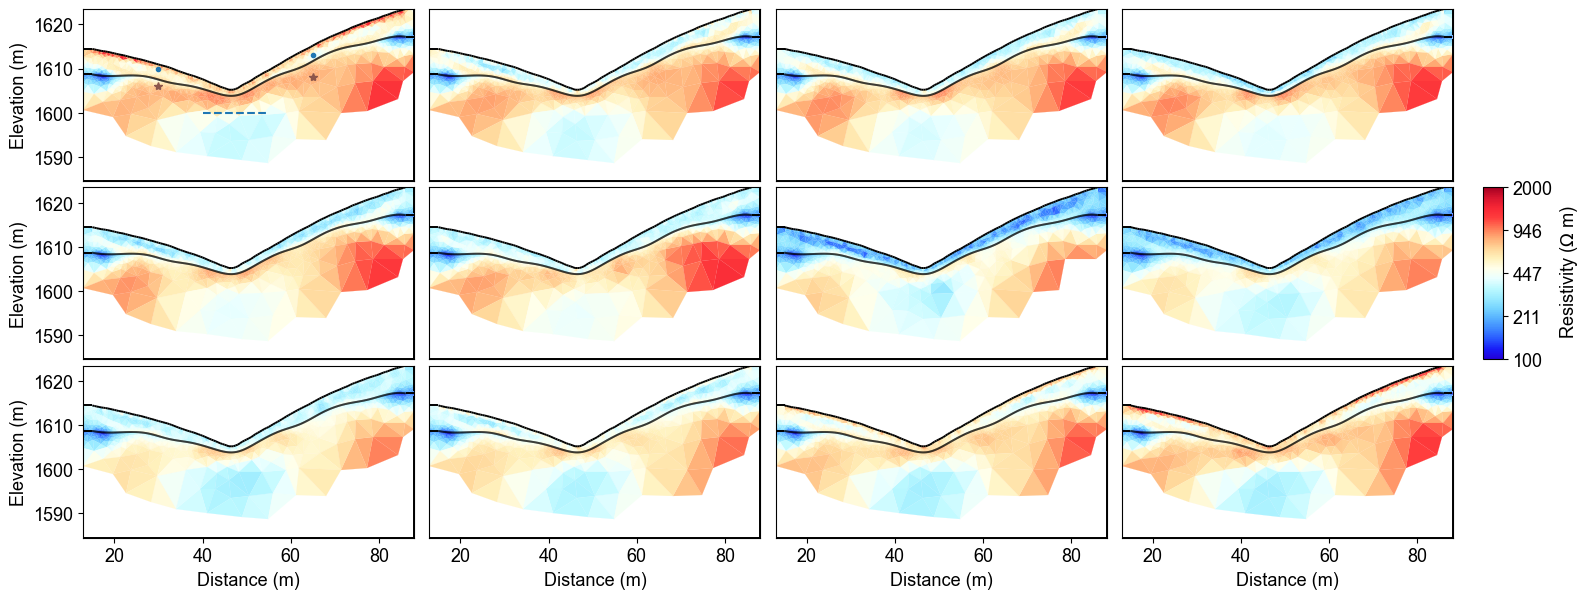

In [ ]:
from palettable.lightbartlein.diverging import BlueDarkRed18_18
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pylab as pylab
params = {'legend.fontsize': 13,
          #'figure.figsize': (15, 5),
         'axes.labelsize': 13,
         'axes.titlesize':13,
         'xtick.labelsize':13,
         'ytick.labelsize':13}

pylab.rcParams.update(params)
plt.rcParams["font.family"] = "Arial"

fixed_cmap = BlueDarkRed18_18.mpl_colormap
fig = plt.figure(figsize=[16, 6])

# Use tight_layout with adjusted parameters to reduce space
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# True resistivity model
for i in range(12):
    row, col = i // 4, i % 4
    ax = fig.add_subplot(3, 4, i+1)
    
    # Add common ylabel only to leftmost panels
    ylabel = "Elevation (m)" if col == 0 else None
    
    # Add resistivity label only to the middle-right panel (row 1, col 3)
    resistivity_label = ' Resistivity ($\Omega$ m)' if (i == 7) else None
    
    # Only show axis ticks on leftmost and bottom panels
    if col != 0:
        ax.set_yticks([])
    
    if row != 2:  # Not bottom row
        ax.set_xticks([])
    else:
        # Add "distance (m)" label to bottom row panels
        ax.set_xlabel("Distance (m)")
    
    # Create the plot
    ax, cbar = pg.show(result.mesh,
                      result.final_models[:,i][result.mesh.cellMarkers()],
                      pad=0.3,
                      orientation="vertical",
                      cMap=fixed_cmap,
                      cMin=100,
                      cMax=2000,
                      ylabel=ylabel,
                      label=resistivity_label,
                      ax=ax,
                      logScale=True,
                      coverage=result.all_coverage[i][result.mesh.cellMarkers()]>-1.2)
    if i ==0:
        ax.plot([30],[1610],'.',c='tab:blue')
        ax.plot([65],[1613],'.',c='tab:blue')

        ax.plot([30],[1606],'.',c='tab:brown')
        ax.plot([65],[1608],'.',c='tab:brown')

        ax.plot([40,55],[1600,1600],ls='--',c='k')
        ax.plot([40,55],[1600,1600],ls='--',c='k')
    # Only keep colorbar for the middle-right panel (row 1, col 3)
    # This corresponds to panel index 7 in a 0-based indexing system
    if i != 7:  # Keep only the colorbar for panel 7
        cbar.remove()

plt.tight_layout()
plt.savefig("results/Structure_WC/timelapse_ert_with structure.tiff", dpi=300, bbox_inches='tight')

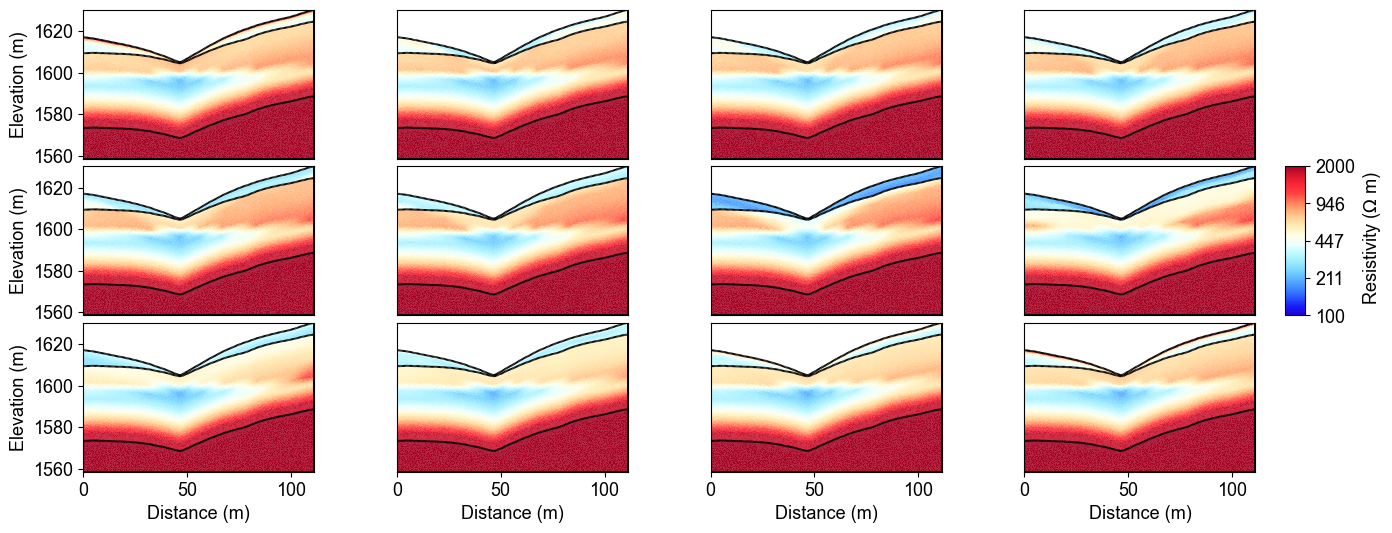

In [15]:
# plot the true resistivity model
fixed_cmap = BlueDarkRed18_18.mpl_colormap
fig = plt.figure(figsize=[16, 6])
mesh = pg.load("results/TL_measurements/mesh.bms")
# Use tight_layout with adjusted parameters to reduce space
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# True resistivity model
for i in range(12):
    row, col = i // 4, i % 4
    ax = fig.add_subplot(3, 4, i+1)
    
    # Add common ylabel only to leftmost panels
    ylabel = "Elevation (m)" if col == 0 else None
    
    # Add resistivity label only to the middle-right panel (row 1, col 3)
    resistivity_label = ' Resistivity ($\Omega$ m)' if (i == 7) else None
    
    # Only show axis ticks on leftmost and bottom panels
    if col != 0:
        ax.set_yticks([])
    
    if row != 2:  # Not bottom row
        ax.set_xticks([])
    else:
        # Add "distance (m)" label to bottom row panels
        ax.set_xlabel("Distance (m)")
    
    # Create the plot
    ax, cbar = pg.show(mesh,
                      np.load("results/TL_measurements/synresmodel/synresmodel"+str((i+1)*30)+".npy"),
                      pad=0.3,
                      orientation="vertical",
                      cMap=fixed_cmap,
                      cMin=100,
                      cMax=2000,
                      ylabel=ylabel,
                      label=resistivity_label,
                      ax=ax,
                      logScale=True)
    
    if i != 7:  # Keep only the colorbar for panel 7
        cbar.remove()

In [46]:
temp0 = np.load("results/TL_measurements/synresmodel/synresmodel30.npy")
np.mean(temp0[mesh.cellMarkers() == 0]), np.mean(temp0[mesh.cellMarkers() == 3]), np.mean(temp0[mesh.cellMarkers() == 2])

(669.2405033128771, 861.5563744709551, 5929.075592855581)

544.1360712045702 569.0974170444465


(array([281., 142., 360., 731., 438., 251.,  94.,  13.,   4.,   6.]),
 array([ 116.82583068,  241.54430827,  366.26278586,  490.98126345,
         615.69974104,  740.41821863,  865.13669622,  989.85517382,
        1114.57365141, 1239.292129  , 1364.01060659]),
 <BarContainer object of 10 artists>)

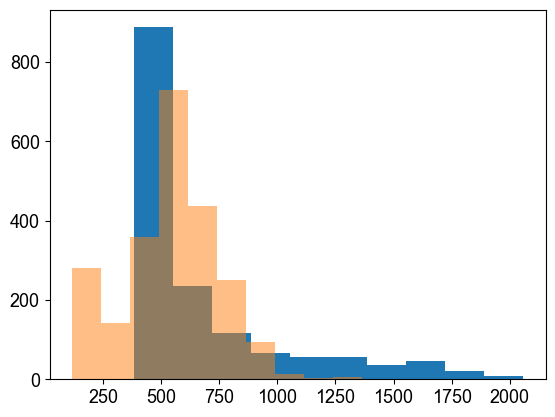

In [47]:
marker = mesh_with_interface.cellMarkers()
marker = marker[marker!=1]
print(np.mean(result.final_models[:,0][marker ==3]),np.mean(result.final_models[:,0][marker ==2]))

plt.hist(temp0[mesh.cellMarkers() == 0])
plt.hist(result.final_models[:,0][marker ==3],alpha=0.5)